In [18]:
import pymust, torch
import numpy as np
from autoray import numpy as npar
import autoray as ar


In [ ]:
class Param:

    def __init__(self):
        pass

    def checkTransducer(self):
        """
        Check whether the description of the transducer is correct.
        """
        #%---------------------------%
        #% Check the PARAM structure %
        #%---------------------------%

        param = param.ignoreCaseInFieldNames()

        #-- 0) Number of elements
        assert 'Nelements' in param, 'The number of elements (PARAM.Nelements) is required.'


        #-- 1) Center frequency (in Hz)
        assert 'fc' in param, 'A center frequency value (PARAM.fc) is required.'
        fc = param.fc # central frequency (Hz)
        assert utils.isnumeric(fc) and np.isscalar(fc) and fc>0, 'The central frequency must be positive.'

        #%-- 2) Pitch (in m)
        assert'pitch' in param,'A pitch value (PARAM.pitch) is required.'
        pitch = param.pitch
        assert utils.isnumeric(pitch) and np.isscalar(pitch) and pitch>0, 'The pitch must be positive.'

        #%-- 3) Element width and/or Kerf width (in m)
        if 'width' in param and 'kerf' in param:
            assert np.abs(pitch-param.width-param.kerf)<utils.eps('single'), 'The pitch must be equal to (kerf width + element width).'
        elif 'kerf' in param:
            param.width = pitch-param.kerf
        elif 'width' in param:
            param.kerf = pitch-param.width
        else:
            raise ValueError('An element width (PARAM.width) or kerf width (PARAM.kerf) is required.')

        #%-- 4) Elevation focus (in m)
        if 'focus' not in param:
            param.focus = np.inf # default = no elevation focusing

        Rf = param.focus
        assert utils.isnumeric(Rf) and np.isscalar(Rf) and Rf>0, 'The element focus must be positive.'

        #%-- 5) Element height (in m)
        if  'height' not in param:
            param.height = np.inf # default = line array

        ElementHeight = param.height
        assert utils.isnumeric(ElementHeight) and np.isscalar(ElementHeight) and ElementHeight>0,'The element height must be positive.'

        #%-- 6) Radius of curvature (in m) - convex array
        if 'radius' not in param:
            param.radius = np.inf # default = linear array

        RadiusOfCurvature = param.radius
        assert utils.isnumeric(RadiusOfCurvature) and np.isscalar(RadiusOfCurvature) and RadiusOfCurvature>0,'The radius of curvature must be positive.'

        #%-- 7) Fractional bandwidth at -6dB (in %)
        if 'bandwidth' not in param:
            param.bandwidth = 75

        assert param.bandwidth>0 and param.bandwidth<200, 'The fractional bandwidth at -6 dB (PARAM.bandwidth, in %) must be in ]0,200['

        #%-- 8) Baffle
        #   An obliquity factor will be used if the baffle is not rigid
        #%   (default = SOFT baffle)
        if  'baffle' not in param:
            param.baffle = 'soft' #  default

        if param.baffle in ['rigid', 'soft'] or np.isscalar(param.baffle):
            if param.baffle <= 0: 
                raise ValueError('The "baffle" field scalar must be positive')
        else:
            raise ValueError('The "baffle" field must be "rigid","soft" or a positive scalar')
        
    def checkTXParameters(self, delaysTX = None, apodTX = None):
        delaysTX = delaysTX.copy()
        #Check the transmit delays
        assert utils.isnumeric(delaysTX) and all(delaysTX[~np.isnan(delaysTX)]>=0),  'DELAYS must be a nonnegative array.'

        NumberOfElements = delaysTX.shape[1]
        # Note: param.Nelements can be required in other functions of the
        #       Matlab Ultrasound Toolbox
        if 'Nelements' in self:
            assert self.Nelements==NumberOfElements, 'DELAYS must be of length PARAM.Nelements.'
        self.Nelements = NumberOfElements

    
        # Note: delaysTX can be a matrix. This option can be used for MLT
        # (multi-line transmit) for example. In this case, each row represents a
        # delay series. For example, for a 4-MLT sequence with a 64-element phased
        # array, delaysTX has 4 rows and 64 columns, i.e. size(delaysTX) = [4 64].

        #delaysTX  should be a row vector
        if len(delaysTX.shape) == 1:
            delaysTX = delaysTX.reshape((1, -1))
        delaysTX = delaysTX.astype(np.float32)


        #%-- 11) Transmit apodization (no unit)
        if  apodTX is None:
            apodTX = np.ones((1,self.NumberOfElements), dtype = np.float32)
        else:
            apodTX = apodTX.copy()
            if isinstance(apodTX, np.ndarray) and len(apodTX.shape) == 1:
                apodTX = apodTX.reshape((1, -1))
            assert (len(apodTX.shape) == 2 and apodTX.shape[0] == 1) and utils.isnumeric(apodTX), 'PARAM.TXapodization must be a vector'
            assert apodTX.shape[1]==self.NumberOfElements, 'PARAM.TXapodization must be of length = (number of elements)'

        #% apodization is 0 where TX delays are NaN:
        idx = np.isnan(delaysTX)
        apodTX[0, np.any(idx, axis = 0)]= 0
        delaysTX[idx] = 0

        # 12) TX pulse: Number of wavelengths
        if 'TXnow' not in self:
            self.TXnow = 1

        NoW = self.TXnow
        assert np.isscalar(NoW) and utils.isnumeric(NoW) and NoW>0, 'PARAM.TXnow must be a positive scalar.'

        #%-- 13) TX pulse: Frequency sweep for a linear chirp
        if 'TXfreqsweep' not in self or np.isinf(NoW):
            self.TXfreqsweep = None

        FreqSweep = self.TXfreqsweep
        assert FreqSweep is None or (np.isscalar(FreqSweep) and utils.isnumeric(FreqSweep) and FreqSweep>0), 'PARAM.TXfreqsweep must be empty (windowed sine) or a positive scalar (linear chirp).'
        return apodTX, delaysTX

    def obtainFrequencies(self, options, maxT = None):
        #%-- FREQUENCY STEP
        if options.isSIMUS or options.isMKMOVIE: #% PFIELD has been called by SIMUS or MKMOVIE
            df = options.FrequencyStep
        else: #% We are in PFIELD only (i.e. not called by SIMUS or MKMOVIE)
            #% The frequency step df is chosen to avoid interferences due to
            #% inadequate discretization.
            #% -- df = frequency step (must be sufficiently small):
            #% One has exp[-i(k r + w delay)] = exp[-2i pi(f r/c + f delay)] in the Eq.
            #% One wants: the phase increment 2pi(df r/c + df delay) be < 2pi.
            #% Therefore: df < 1/(r/c + delay).
            df = 1/(np.max(r/c) + np.max(self.delaysTX))
            df = options.FrequencyStep*df
            #% note: df is here an upper bound; it will be recalculated below
            self.df = df

        #%-- FREQUENCY SAMPLES
        Nf = int(2*np.ceil(self.fc/df)+1) # number of frequency samples
        f = np.linspace(0,2*self.fc,Nf) # frequency samples
        df = f[1]  #% update the frequency step
        #%- we keep the significant components only by using options.dBThresh
        S = np.abs(self.pulseSpectrum(2*np.pi*f)*self.probeSpectrum(2*np.pi*f))

        GdB = 20*np.log10(1e-200 + S/np.max(S))# % gain in dB
        id = np.where(GdB >options.dBThresh)
        IDX = np.zeros(f.shape) != 0.
        IDX[id[0][0]:id[0][-1]+1] = True

        f = f[IDX]
        return f

In [ ]:
import numpy, importlib
class NumericalEngine:
    def __init__(self, backend = 'numpy', device = 'cpu'):
        self.device = device
        if backend == 'numpy':
            self.isNumpy = True
            self.backend = numpy
            self.backend_name = 'numpy'
            if self.device != 'cpu':
                raise ValueError('Numpy backend only supports cpu device')  
        elif backend == 'torch':
            ar = importlib.import_module('autoray')
            self.isNumpy = False
            self.backend_name = 'torch'
            self.backend = ar.get_namespace('torch')
            self.backend.set_default_device(device)
        else:
            raise ValueError('Unsupported backend')
        
    def to_numpy(self, x):
        if self.isNumpy:
            return x
        elif self.device != 'cpu':
            return x.detach().to('cpu').numpy()
        else:
            return x.detach().numpy()
        
    

In [ ]:
from pymust import utils
import numpy

def reshape_fortran(x, shape):
    if isinstance(x, numpy.ndarray):
        return x.reshape(shape, order = 'F')
    else:
        # Works for torch tensors
        if len(x.shape) > 0:
            x = x.permute(*reversed(range(len(x.shape))))
        return x.reshape(*reversed(shape)).permute(*reversed(range(len(shape))))

# Ugly optimisation trick, of loop unraveling, as np.mean/np.sum has a large overhead for iterating over few dimesions
# for i in range(1, 10):
#   r = '+'.join([f'X[...,{j}]' for j in range(i)])
#   print(f'average_function_by_i[{i}] = lambda X: ({r})/{i}')
average_function_by_i = [None] * 10
average_function_by_i[1] = lambda X: (X[...,0])/1
average_function_by_i[2] = lambda X: (X[...,0]+X[...,1])/2
average_function_by_i[3] = lambda X: (X[...,0]+X[...,1]+X[...,2])/3
average_function_by_i[4] = lambda X: (X[...,0]+X[...,1]+X[...,2]+X[...,3])/4
average_function_by_i[5] = lambda X: (X[...,0]+X[...,1]+X[...,2]+X[...,3]+X[...,4])/5
average_function_by_i[6] = lambda X: (X[...,0]+X[...,1]+X[...,2]+X[...,3]+X[...,4]+X[...,5])/6
average_function_by_i[7] = lambda X: (X[...,0]+X[...,1]+X[...,2]+X[...,3]+X[...,4]+X[...,5]+X[...,6])/7
average_function_by_i[8] = lambda X: (X[...,0]+X[...,1]+X[...,2]+X[...,3]+X[...,4]+X[...,5]+X[...,6]+X[...,7])/8
average_function_by_i[9] = lambda X: (X[...,0]+X[...,1]+X[...,2]+X[...,3]+X[...,4]+X[...,5]+X[...,6]+X[...,7]+X[...,8])/9

def average_over_last_axis(X):
    if X.shape[-1] < len(average_function_by_i):
        return average_function_by_i[X.shape[-1] ](X)
    else:
        return np.mean(X, axis = -1)

eps = 1e-16

#GB TODO: add wait bar
#GB TODO: allow parallelization

e = Engine('torch', 'cpu')

def pfield(x : numpy.ndarray,y : numpy.ndarray, z: numpy.ndarray, 
           delaysTX : numpy.ndarray, param: utils.Param, 
           options : utils.Options = None, engine = numericalEngine.NumpyEngine, gradientsTx = False):
#PFIELD   RMS acoustic pressure field of a linear or convex array
#   RP = PFIELD(X,Y,Z,DELAYS,PARAM) returns the radiation pattern of a
#   uniform LINEAR or CONVEX array whose elements are excited at different
#   time delays (given by the vector DELAYS). The radiation pattern RP is
#   given in terms of the root-mean-square (RMS) of acoustic pressure. The
#   characteristics of the array and transmission must be given in the
#   structure PARAM (see below for details). The radiation pattern is
#   calculated at the points specified by (X,Y,Z).
#
#   RP = PFIELD(X,[],Z,DELAYS,PARAM)
#   disregards elevation focusing (PARAM.focus is ignored) and assumes that
#   Y=0 (2-D space). The computation is faster in 2-D.
#
#
#   Units: X,Y,Z must be in m; DELAYS must be in s.
#
#   DELAYS can be a matrix. This syntax can be used to simulate MLT
#   (multi-line transmit) sequences. In this case, each ROW represents a
#   delay series. For example, to create a 4-MLT sequence with a 64-element
#   phased array, the DELAYS matrix must have 4 rows and 64 columns (size =
#   [4, 64]).
#
#   PFIELD is called by SIMUS to simulate ultrasound RF radio-frequency
#   signals generated by an ultrasound uniform linear or convex array.
#
#   ---
#   NOTE #1: X-, Y-, and Z-axes
#   Conventional axes are used:
#   i)  For a LINEAR array, the X-axis is PARALLEL to the transducer and
#       points from the first (leftmost) element to the last (rightmost)
#       element (X = 0 at the CENTER of the transducer). The Z-axis is
#       PERPENDICULAR to the transducer and points downward (Z = 0 at the
#       level of the transducer, Z increases as depth increases). The
#       Y-axis is such that the coordinates are right-handed.
#   ii) For a CONVEX array, the X-axis is parallel to the chord and Z = 0
#       at the level of the chord.
#   ---
#   NOTE #2: Simplified method: Directivity
#   By default, the calculation is made faster by assuming that the
#   directivity of the elements is dependent only on the central frequency.
#   This simplification very little affects the pressure field in most
#   situations (except near the array). To turn off this option, use
#   OPTIONS.FullFrequencyDirectivity = true.
#   (see ADVANCED OPTIONS below).
#   ---
#
#   PARAM is a structure (defined in pymust.utils) that contains the following fields:
#   -------------------------------------------------------
#       *** TRANSDUCER PROPERTIES ***
#   1)  PARAM.fc: central frequency (in Hz, REQUIRED)
#   2)  PARAM.pitch: pitch of the array (in m, REQUIRED)
#   3)  PARAM.width: element width (in m, REQUIRED)
#        or PARAM.kerf: kerf width (in m, REQUIRED)
#        note: width = pitch-kerf
#   4)  PARAM.focus: elevation focus (in m, ignored if Y is not given)
#            The default is Inf (no elevation focusing)
#   5)  PARAM.height: element height (in m, ignored if Y is not given)
#            The default is Inf (no elevation focusing)
#   6)  PARAM.radius: radius of curvature of the probe (in m)
#            The default is Inf (rectilinear array)
#   7)  PARAM.bandwidth: pulse-echo 6dB fractional bandwidth (in %)
#            The default is 75%.
#   8)  PARAM.baffle: property of the baffle:
#            'soft' (default), 'rigid', or a scalar > 0.
#            See "Note on BAFFLE properties" below for details
#
#       *** MEDIUM PARAMETERS ***
#   9)  PARAM.c: longitudinal velocity (in m/s, default = 1540 m/s)
#   10) PARAM.attenuation: attenuation coefficient (dB/cm/MHz, default: 0)
#            Notes: A linear frequency-dependence is assumed.
#                   A typical value for soft tissues is ~0.5 dB/cm/MHz.
#
#       *** TRANSMIT PARAMETERS ***
#   11) PARAM.TXapodization: transmit apodization (default: no apodization)
#   12) PARAM.TXnow: number of wavelengths of the TX pulse (default: 1)
#   13) PARAM.TXfreqsweep: frequency sweep for a linear chirp (default: [])
#                          To be used to simulate a linear TX chirp.
#
#
#   Note on CHIRP signals:
#   ---------------------
#   Linear chirps are characterized by PARAM.TXnow, PARAM.fc and
#   PARAM.TXfreqsweep. The transmitted pulse The transmitted pulse has a
#   duration of approximately T (= PARAM.TXnow/PARAM.fc), with the
#   amplitude and phase defined over the time interval -T/2 to +T/2. The
#   total frequency sweep is DeltaF (= PARAM.TXfreqsweep): the frequencies
#   changes linearly from (PARAM.fc - DeltaF/2) to (PARAM.fc + DeltaF/2)
#   in the defined time interval.
#
#
#   Note on BAFFLE property:
#   -----------------------
#   In PFIELD, it is assumed by default that the array elements are
#   embedded in an infinite SOFT baffle. To modify the property of the
#   baffle, modify the field PARAM.baffle:
#       1) 'rigid'
#       2) 'soft' (this is the default)
#       3) a nonnegative scalar Alpha,
#          with Alpha = (medium impedance)/(baffle impedance)
#          Note: Alpha = 0 => 'rigid'; Alpha >> 1 => 'soft'
#
#   The baffle property affects the obliquity factor included in the
#   directivity of the elements. This obliquity factor is not 1 if the
#   baffle is not rigid. A general case (see case #3 below) can be chosen
#   by specifying an impedance ratio. For details, refer to the
#   corresponding papers.
#   1) For a rigid baffle => obliquity factor = 1.
#   2) For a soft baffle => obliquity factor = cos(Theta).
#      Selfridge et al. Appl Phys Lett 37(1), 35-36 (1980)
#      "A theory for the radiation pattern of a narrow-strip acoustic
#      transducer." <a
#      href="matlab:web('http://scitation.aip.org/content/aip/journal/apl/37/1/10.1063/1.91692')">Paper here</a>
#   3) General baffle => obliquity factor = cos(Theta)/(cos(Theta)+Alpha)
#      with Alpha = (medium impedance)/(baffle impedance).
#      Pesqu� et al. IEEE Ultrasonics Symposium, (1984)
#      "Effect of the planar baffle impedance in acoustic radiation of a
#      phased array element theory and experimentation." <a
#      href="matlab:web('http://ieeexplore.ieee.org/xpl/articleDetails.jsp?arnumber=1535402')">Paper here</a>
#      Example: For a baffle of impedance 2.8 MRayl (epoxy) adjacent to
#               soft tissues of impedance 1.6 MRayls, alpha = 1.75.
#
#
#   ADVANCED OPTIONS:
#   ----------------
#       %-- FREQUENCY SAMPLES --%
#   1)  Only frequency components of the transmitted signal in the range
#       [0,2fc] with significant amplitude are considered. The default
#       relative amplitude is -60 dB in PFIELD. You can change this value
#       by using the following:
#           [...] = PFIELD(...,OPTIONS),
#       where OPTIONS.dBThresh is the threshold in dB (default = -60).
#   ---
#       %-- FULL-FREQUENCY DIRECTIVITY --%   
#   2)  By default, the directivity of the elements depends on the center
#       frequency only. This makes the algorithm faster. To make the
#       directivities fully frequency-dependent, use: 
#           [...] = PFIELD(...,OPTIONS),
#       with OPTIONS.FullFrequencyDirectivity = true (default = false).
#   ---
#       %-- ELEMENT SPLITTING --%   
#   3)  Each transducer element of the array is split into small segments.
#       The length of these small segments must be small enough to ensure
#       that the far-field model is accurate. By default, the elements are
#       split into M segments, with M being defined by:
#           M = ceil(element_width/smallest_wavelength);
#       To modify the number M of subelements by splitting, you may adjust
#       OPTIONS.ElementSplitting. For example, OPTIONS.ElementSplitting = 1
#   ---
#
#
#   Notes regarding the model & REFERENCES:
#   --------------------------------------
#   1) PFIELD works for uniform linear or convex arrays. A uniform array
#      has identical elements along a rectilinear or curved line in space
#      with uniform spacing. Each element is split into small segments (if
#      required). The radiation patterns in the x-z plane are derived by
#      using Fraunhofer (far-field) equations. Those in the x-y elevational
#      plane are derived by using a Fresnel (paraxial) approximation.
#   2) The paper that describes the first 2-D version of PFIELD is:
#      SHAHRIARI S, GARCIA D. Meshfree simulations of ultrasound vector
#      flow imaging using smoothed particle hydrodynamics. Phys Med Biol,
#      2018;63:205011. <a
#      href="matlab:web('https://www.biomecardio.com/publis/physmedbio18.pdf')">PDF here</a>
#   3) The paper that describes the theory of the full (2-D + 3-D) version
#      of PFIELD is under review.
#
    extra_outputs = {}
    np = engine.backend
    mysinc = lambda x = None: np.sin(np.abs(x) + eps)/ (np.abs(x) + eps) # [note: In MATLAB/numpy, sinc is sin(pi*x)/(pi*x)]

    if x is None or (isinstance(x, list) and len(x) == 0):
        x =  np.array([])
    if y is None or (isinstance(y, list) and len(y) == 0):
        y =  np.array([])
    if z is None or (isinstance(z, list) and len(z) == 0):
        z =  np.array([])

    if options is None:
        options = utils.Options()

    if y is None or len(y) == 0 or np.all(np.abs(y) < 1e-9):
        ElevationFocusing = False
        assert len(x.shape) == len(z.shape) and  all([i ==j for i,j in zip(x.shape, z.shape)]), 'X and Z must be of same size.'
        y = np.zeros(x.shape, dtype = np.float32)
    else:
        ElevationFocusing = True
        assert x.shape == y.shape and y.shape == z.shape, 'X, Y, and Z must be of same size.'
    
    # Check if PFIELD is called by SIMUS or MKMOVIE
    isSIMUS = False
    isMKMOVIE = False
    if 'CallFun' in options:
        isSIMUS = options.CallFun == 'simus'
        isMKMOVIE = options.CallFun == 'mkmovie'    
        
    #GB: TODO:  For the moment no statistics on usage.

    param.checkTransducer()
    ElementWidth = param.ElementWidth
    fc = param.fc
    bandwidth = param.bandwidth
    
    delaysTX, apodTX = param.checkTXParameters(delaysTX) 
   
    #%-- 9) Longitudinal velocity (in m/s)
    if  'c' not in param:
        param.c = 1540 # % default value

    c = param.c  # speed of sound (m/s)

    #%-- 10) Attenuation coefficient (in dB/cm/MHz)
    if  'attenuation' not in param:  #no attenuation, alpha_dB = 0
        param.attenuation = 0
        alpha_dB = 0
    else:
        alpha_dB = param.attenuation
        assert numpy.isscalar(alpha_dB) and utils.isnumeric(alpha_dB) and alpha_dB>=0, 'PARAM.attenuation must be a nonnegative scalar'


    #%----------------------------------%
    #% END of Check the PARAM structure %
    #%----------------------------------%



    #%-----------------------------%
    #% Check the OPTIONS structure %
    #%-----------------------------%

    options = options.ignoreCaseInFieldNames()

    #%-- 1) dB threshold
    #%     (in dB: faster computation if lower value, but less accurate)
    if 'dBThresh' not in options:
        options.dBThresh = -60 # default is -60dB in PFIELD

    assert utils.isnumeric(options.dBThresh) and options.dBThresh<=0,'OPTIONS.dBThresh must be a nonpositive scalar.'

    #%-- 2) Frequency-dependent directivity?
    if utils.isfield(options,'FullFrequencyDirectivity'):
        isFFD = options.FullFrequencyDirectivity
    else:
        isFFD = False # % default
        # By default, the directivity of the elements depends on the center
        # frequency only. This makes the algorithm faster. 

    assert  isinstance(isFFD, bool) ,'OPTIONS.FullFrequencyDirectivity must be a logical scalar (true or false).'

    #%-- 3) Element splitting
    #%
    #% --- A short note about the algorithm:
    #% A far-field model is used in PFIELD. Each transducer element of the array
    #% is split into M small segments, so that these M small segments are
    #% smaller than one wavelength. The far-field condition is acceptable for
    #% these small segments.
    #%---
    if utils.isfield(options,'ElementSplitting') and not options.ElementSplitting is None:
        M = int(options.ElementSplitting)
        assert M==np.round(M) and M>0, 'OPTIONS.ElementSplitting must be a positive integer.'
    else:
        LambdaMin = c/(fc*(1+param.bandwidth/200))
        M = int(numpy.ceil(ElementWidth/LambdaMin))

    #%-- 4) Wait bar NOTE GB: this does not do nothing yet
    if not utils.isfield(options,'WaitBar'):
        options.WaitBar = True

    assert  utils.islogical(options.WaitBar), 'OPTIONS.WaitBar must be a logical scalar (true or false).'

    #%-- Advanced (masked) options: Frequency step (scaling factor)
    #% The frequency step is determined automatically. It is tuned to avoid
    #% significant interferences due to unadapted discretization. The frequency
    #% step can also be adjusted by using a scaling factor. For a fast check,
    #% you may use a scaling factor>1. For a smoother result, you may use a
    #% scaling factor<1.
    if not utils.isfield(options,'FrequencyStep'):
        options.FrequencyStep = 1

    assert numpy.isscalar(options.FrequencyStep) and utils.isnumeric(options.FrequencyStep) and options.FrequencyStep>0, 'OPTIONS.FrequencyStep must be a positive scalar.'

    # DR: Possibly add explanation of casting RC to single precision
    if options.RC is not None and len(options.RC):
        options.RC = options.RC.astype(np.float32)
    
    #%------------------------------------%
    #% END of Check the OPTIONS structure %
    #%------------------------------------%



    #%-----
    #% SIMUS and MKMOVIE first run a PFIELD with empty X,Y,Z to detect possible
    #% syntax errors.
    if isSIMUS and len(x) == 0:
        return [], [], []
    if isMKMOVIE and len(x) == 0 and not options.get('computeIndices', False):
        return [], [], []
    #-----


    #%------------------------------------%
    #% POINT LOCATIONS, DISTANCES & GRIDS %
    #%------------------------------------%
    if len(x.shape) == 1:
        siz0 = (x.shape[0], 1)
    else:
        siz0 = x.shape
    nx = numpy.prod(x.shape)
    #%-- Coordinates of the points where pressure is needed
    x = reshape_fortran(x, (-1, 1)) 
    y = reshape_fortran(y, (-1, 1)) 
    z = reshape_fortran(z, (-1, 1)) 

    if isMKMOVIE:
        x = np.concatenate((x, np.array(options.x).reshape((-1,1))))
        z = np.concatenate([z, np.array(options.z).reshape((-1,1))])
        y = np.concatenate([y, np.zeros((len(options.x), 1))])
        #% Note with MKMOVIE:
        #% We must consider the points of the image grid + the points of the
        #% scatterers (if any). The scatterer coordinates are in options.x and
        #% options.z.
        #% Note: there is no elevation focusing with MKMOVIE (2-D only).

    xe, ze, THe, h = param.getElementPositions()

    # Cast x, y, z and xe, ze, THe, h to device, if needed
    xe = np.asarray(xe)
    ze = np.asarray(ze)
    THe = np.asarray(THe)
    h = np.asarray(h)
    x = np.asarray(x, dtype = np.float32)
    y = np.asarray(y, dtype = np.float32)
    z = np.asarray(z, dtype = np.float32)
    
    #%-- Centroids of the sub-elements
    #%-- note: The elements have been split into M sub-elements.
    #% X-position (xi) and Z-position (zi) of the centroids of the sub-elements
    #% (relative to the centers of the transducer elements).
    #% The values in xi,zi are in the range ]-ElementWidth/2 ElementWidth/2[
    #% (if M=1, then xi = zi = 0 for a rectilinear array).
    SegLength = param.ElementWidth/M
    tmp = -param.ElementWidth/2 + SegLength/2 + np.arange(M)*SegLength
    xi = tmp.reshape((1,1,M))*np.cos(THe)[:,:,None]
    zi = tmp.reshape((1,1,M))*np.sin(-THe)[:,:,None]
    #%-- Out-of-field points
    #% Null pressure will be assigned to out-of-field points.
    isOUT = z<0
    if numpy.isfinite(param.RadiusOfCurvature):
        isOUT = np.logical_or(isOUT, (x**2+(z+h)**2) <=param.RadiusOfCurvature**2)
    
    #%-- Variables that we need:
    #%
    #% Note: r = distance between the segment centroid and the point of interest
    #%       Th = angle relative to the element normal axis.
    #%       sinT = sine of the angle relative to the element normal axis.
    #%       r, Th, and sinT are of size [numel(x) NumberOfElements M].
    #%
    dxi = x.reshape((-1,1,1))-xi-xe.reshape((1, -1, 1))
    d2 = dxi**2+(z.reshape((-1,1,1))-zi-ze.reshape((1, -1, 1)))**2

    #%---
    r = np.sqrt(d2+y.reshape((-1,1,1))**2) #.astype(np.float32)
    #%---
    #% we'll have 1/sqrt(r) or 1/r:
    #% small d2 values are replaced by lambda/2
    #% lambda = c/fc; smallD = lambda/2;
    smallD = (c/fc/2)
    r[r<smallD] = smallD

    eps_sp = np.finfo(np.float32).eps
    Th = np.arcsin((dxi +eps_sp)/(np.sqrt(d2)+eps_sp))-THe.reshape((1,-1,1))
    sinT = np.sin(Th)
    # clear dxi d2 Remove if needed for clear memory
    dxi, d2 = None, None # Clear memory if needed

    #%-------------------------------------------%
    #% end of POINT LOCATIONS, DISTANCES & GRIDS %
    #%-------------------------------------------%

    #%-------------------%
    #% FREQUENCY SPECTRA %
    #%-------------------%

    #GB: Same as getpulse!! Make common function

    #%-- FREQUENCY SPECTRUM of the transmitted pulse
    pulseSpectrum = param.getPulseSpectrumFunction(param.TXfreqsweep)


    #%-- FREQUENCY RESPONSE of the ensemble PZT + probe
    probeSpectrum = param.getProbeFunction()
    
    # Note: The spectrum of the pulse (pulseSpectrum) will be then multiplied
    # by the frequency-domain tapering window of the transducer (probeSpectrum)

    #%-- FREQUENCY STEP
    # GB TODO: this should go to param.
    if isSIMUS or isMKMOVIE: #% PFIELD has been called by SIMUS or MKMOVIE
        df = options.FrequencyStep
    else: #% We are in PFIELD only (i.e. not called by SIMUS or MKMOVIE)
        #% The frequency step df is chosen to avoid interferences due to
        #% inadequate discretization.
        #% -- df = frequency step (must be sufficiently small):
        #% One has exp[-i(k r + w delay)] = exp[-2i pi(f r/c + f delay)] in the Eq.
        #% One wants: the phase increment 2pi(df r/c + df delay) be < 2pi.
        #% Therefore: df < 1/(r/c + delay).
        if engine.device == 'meta':
            # GB WARNING: Dummy code, since meta device has no values and it is not possible to compute. Just to avoid a crash
            df = c/0.1
        else:
            df = 1/(engine.to_numpy(np.max(r/c)) + numpy.max(delaysTX))

        df = options.FrequencyStep*df
        #% note: df is here an upper bound; it will be recalculated below
        param.df = df

    #%-- FREQUENCY SAMPLES
    Nf = int(2*numpy.ceil(param.fc/df)+1) # number of frequency samples
    f =  numpy.linspace(0,2*param.fc,Nf) # frequency samples
    df = f[1]  #% update the frequency step
    #%- we keep the significant components only by using options.dBThresh
    S = numpy.abs(pulseSpectrum(2*numpy.pi*f)*probeSpectrum(2*numpy.pi*f))

    GdB = 20*numpy.log10(1e-200 + S/numpy.max(S))# % gain in dB
    id = numpy.where(GdB >options.dBThresh)
    IDX = numpy.zeros(f.shape) != 0.
    IDX[id[0][0]:id[0][-1]+1] = True

    f = f[IDX]
    nSampling = len(f)


    #-- Frequency correction (added on April 24, 2023; removed on Nov 8, 2023) on MUST
    #   Note: The frequencies are shifted such that the center frequency for a
    #         a pulse-echo is exactly PARAM.fc.
    # pulse-echo spectrum
    # F = pulseSpectrum(2*np.pi*f)*probeSpectrum(2*np.pi*f)**2
    # predicted center frequency
    # P = np.abs(F)**2; #% power
    # Fc = np.trapz(f*P)/np.trapz(P)
    # corrected frequencies
    # f = f+Fc-fc

    #%-- For MKMOVIE only: IDX is required in MKMOVIE
    if isMKMOVIE and x is None:
         return [], [], IDX

    #%-- we need VECTORS
    pulseSPECT = pulseSpectrum(2*np.pi*f) # pulse spectrum
    probeSPECT = probeSpectrum(2*np.pi*f) # probe response

    #%--------------------------%
    #% end of FREQUENCY SPECTRA %
    #%--------------------------%


    """
    %-- Wait bar
    options.WaitBar = options.WaitBar & (nSampling>10);
    if options.WaitBar
        if isSIMUS
            wbtitle = 'Let SIMUS do the work for you...';
            wbname = 'SIMUS / www.biomecardio.com';
        elseif isMKMOVIE
            wbtitle = 'Let MKMOVIE do the work for you...';
            wbname = 'MKMOVIE / www.biomecardio.com';
        else
            wbtitle = 'Let PFIELD do the work for you...';
            wbname = 'PFIELD / www.biomecardio.com';
        end
        tstart = tic;
        hwb = waitbar(0,wbtitle,'Name',wbname);
    end
    """

    #%-- Initialization
    RP = 0 # % RP = Radiation Pattern
    if isSIMUS:
        #%- For SIMUS only (we need the full spectrum of RX signals):
        SPECT = np.zeros((nSampling, param.NumberOfElements), dtype = np.complex64)
    else:
        #%- For MKMOVIE only (we need the full spectrum of the pressure field):
        #%- For using PFIELD alone we need the spectrum recieved on each point:
        SPECT = np.zeros((nSampling, nx), dtype = np.complex64)

    #%-- Obliquity factor (baffle property)
    #%   An obliquity factor is required if the baffle is not rigid.
    #%   [Th = angle relative to the element normal axis]
    if param.baffle != 'rigid':
        if param.baffle == 'soft':
            ObliFac = np.cos(Th)
        else: # % param.baffle is a scalar
            ObliFac = np.cos(Th)/(np.cos(Th)+param.baffle)
    else: # % 1 if rigid baffle
        ObliFac = np.ones(Th.shape, np.float32)

    ObliFac[np.abs(Th)>=np.pi/2] = utils.eps('single')


    #%-- Note on Attenuation
    #% Reference: Diagnostic ultrasound imaging - inside out (T.L. Szabo)
    #%            Chapter 4: Attenuation
    #% Key reference: Acoustics for ultrasound imaging (Ben Cox, 2013)
    #%                Chapter 5: Acoustic attenuation and absorption
    #% We will use this attenuation-based wavenumber:
    #%   kwa = alpha_dB/8.69*f(k)/1e6*1e2; % P(z,f) = P0 exp(-alpha*f*z/8.69)
    #%   note: 20/log(10) ~ 8.69

   # %-- EXPONENTIAL arrays of size [numel(x) NumberOfElements M]
    kw = 2*np.pi*f[0]/c # % wavenumber
    kwa = alpha_dB/8.69*f[0]/1e6*1e2 # % attenuation-based wavenumber
    EXP = np.asarray(np.exp(-kwa*r + (kw*r*1j)), dtype = np.complex64) #; % faster than exp(-kwa*r+1j*kw*r)
    #%-- Exponential array for the increment wavenumber dk
    dkw = 2*np.pi*df/c
    dkwa = alpha_dB/8.69*df/1e6*1e2
    EXPdf = np.asarray(np.exp((-dkwa + dkw*1j)*r), dtype = np.complex64)

    #%-- We replace EXP by EXP.*ObliFac./r or EXP.*ObliFac./sqrt(r)

    if ElevationFocusing:
        EXP = EXP*ObliFac/r
        rm = average_over_last_axis(r); 
    else:
        EXP = EXP*ObliFac/np.sqrt(r)

    #clear ObliFac r


    #%-- If PFIELD is called by MKMOVIE
    #%   Other matrices are needed if scatterers are present. If scatterers are
    #%   added in the movie, it is needed to simulate the propagation of the
    #%   backscattered echoes. We thus need the distances between the scatterers
    #%   and grid-points, and the corresponding EXP_RC matrix.
    if isMKMOVIE and options.RC is not None:
        dx = x[:nx].reshape((-1,1))-np.array(options.x).reshape((1, -1))
        dz = z[:nx].reshape((-1,1))-np.array(options.z).reshape((1,-1))
        r_RC = np.sqrt(dx**2 + dz**2)
        
        #% EXP_RC = exp((-kwa+1i*kw)*r_RC);
        EXP_RC = np.exp(-kwa*r_RC + 1j*(kw*r_RC,2*np.pi)).astype(np.complex64)
        EXPdf_RC = np.exp((-dkwa + 1j*dkw)*r_RC).astype(np.complex64)

    #%-- Simplified directivity (if not dependent on frequency)
    #% In the "simplified directivity" version, the directivity of the elements
    #% depends on the center frequency ONLY. It is thus not needed to calculate
    #% the directivity array (DIR) in the following for-loop. This directivity
    #% DIR is included in the variable EXP to reduce storage.

    if not isFFD:
        kc = 2*np.pi*fc/c # % center wavenumber
        DIR = mysinc(kc*SegLength/2*sinT) # % directivity of each segment
        EXP = EXP*DIR #
        #clear DIR


    #%-- Multi-Gaussian beam model (MGBM)
    #% A multi-Gaussian beam model is used when integrating the elevation
    #% focusing.
    if ElevationFocusing:
        A,B = MGBMcoeff(4)
        #% Note: The rectangular function is decomposed into a number of
        #%       Gaussian functions, defined by A(n)*exp(-B(n)*y^2), with A(n)
        #%       and B(n) being complex coefficients. Four coefficients offers
        #       a good compromise.
        alpha = 1j/2*(1/param.focus-1/rm)
        gamma = 1j*y**2/2/rm
        beta2 = (-(y/rm)**2).astype(np.complex128)
        #clear rm
        Nmgbm = max(3,int(np.round(nSampling/20)))
        k4mgbm = np.round(np.linspace(1,nSampling,Nmgbm))
        #% (the MGBM field won't be calculated at each step)

    # Make sure it is consistent, and all arrays are in the device, and the engine they should
    EXP = np.asarray(EXP, dtype = np.complex64)
    tmp = np.asarray(tmp, dtype = np.complex64)
    if gradientsTx:
        # This is to compute the gradients for the transmit
        if engine.backend_name != 'torch':
            raise ValueError('When using gradients, only torch engine is allowed.')
        delaysTX = np.torch.asarray(delaysTX, dtype = np.float32, requires_grad=True)
        APOD = np.torch.asarray(param.TXapodization.flatten(), dtype = np.float32, requires_grad=True)
        extra_outputs['delaysTX'] = delaysTX
        extra_outputs['APOD'] = APOD

    else:
        delaysTX = np.asarray(delaysTX, dtype = np.float32)
        APOD = np.asarray(param.TXapodization.flatten(), dtype = np.float32)



    #%-----------------------------%
    #% SUMMATION OVER THE SPECTRUM %
    #%-----------------------------%
    # TODO GB: process several frequencies at the same time might remove some overhead of numpy calls

    for k  in range(nSampling):

        kw = 2*np.pi*f[k]/c #; % wavenumber
        
        #%--- MGBM = multi-Gaussian beam model
        #% The MGBM is used to simulate the focused beams in the elevation
        #% direction. These lines are run if ElevationFocusing is true.
        if ElevationFocusing and (k + 1) in k4mgbm:
            #% (the MGBM field is not recalculated at each step)
            MGBM = 0
            if np.all(np.abs(y)<utils.eps('single')):
                for n,_ in enumerate(A):
                    MGBM = MGBM + A[n]*np.sqrt(np.pi/(kw*alpha + B[n]/ElementHeight**2))

            else:
                MGBM = np.zeros(y.shape, dtype = np.complex64)
                for n,_ in enumerate(A):
                    tmp = 1/(kw*alpha + B[n]/ElementHeight**2)
                    MGBM = MGBM + A[n]*np.sqrt(np.pi*tmp)* np.exp(kw**2*beta2/4*tmp + kw*gamma)
                
            
        
        #%-- Exponential array of size [numel(x) NumberOfElements M]
        #% For all k, we need: EXP = exp((-kwa+1i*kw)*r)
        #%                         with kw = 2*pi*f(k)/c;
        #%                     and with kwa = alpha_dB/8.7*f(k)/1e6*1e2;
        #% Since f(k) = f(1)+(k-1)df, we use the following recursive product:
        if k>0:
            EXP = EXP*EXPdf
            #% If PFIELD is called by MKMOVIE and if scatterers are present:
            if isMKMOVIE and not utils.isEmpty(options.RC):
                EXP_RC = EXP_RC*EXPdf_RC


            
        #%-- Directivity (if frequency-dependent)
        if isFFD: #% isFFD = true -> frequency-dependent directivity
            DIR = kw*SegLength/2*sinT
            DIR = mysinc(DIR)

            
        #%-- Radiation patterns of the single elements
        #% They are the combination of the far-field patterns of the M small
        #% segments that make up the single elements
        #%--
        if isFFD: #% isFFD = true -> frequency-dependent directivity
            #TODO: CHECK THIS IS CORRECT
            RPmono=  average_over_last_axis(DIR*EXP) #; % summation over the M small segments
        else: # % isFFD = false: the directivity depends on center frequency only
            #% note: the directivity (DIR) has already been included in EXP
            if M>1:            
                RPmono = average_over_last_axis(EXP); #% summation over the M small segments
            else:
                RPmono = EXP

        if len(RPmono.shape) == 3 and RPmono.shape[2] == 1:
            RPmono = RPmono.reshape((RPmono.shape[0],RPmono.shape[1]))
        
        
        #%-- Complete the radiation patterns of the single elements by including
        #%   the elevation focusing, if required
        if ElevationFocusing:
            RPmono = RPmono*MGBM

            
        #%-- Transmit delays + Transmit apodization
        #% use of SUM: summation over the number of delay series (e.g. MLT)
        #GB WARNING,  HERE delays are a row vector instead of a column as in matlab

        DELAPOD = np.sum(np.exp(1j*kw*c*delaysTX), 0) *APOD
        
        #%-- Summing the radiation patterns generating by all the elements
        RPk = RPmono@DELAPOD.reshape((-1, 1))
        #RPk = np.einsum('ij,j->i', RPmono, DELAPOD)
        #RPk = RPk.reshape((-1,1))

        #%- include spectrum responses:
        RPk = pulseSPECT[k]*RPk* probeSPECT[k]

        RPk[isOUT] = 0 #<- if not jax
        
       #%-- Output
        if isMKMOVIE: # % for MKMOVIE only (spectrum of the pressure field)
            SPECT[k,:] = RPk[:nx, 0]
            if not utils.isEmpty(options.RC):
                SPECT[k,:] += EXP_RC @ (RPk[nx:].flatten()*options.RC) 

        elif isSIMUS: #% Receive: for SIMUS only (spectra of the RF signals)
            SPECT[k,:] = probeSPECT[k]  #... % the array bandwidth is considered

            SPECT[k,:] *= ((RPk.flatten()*options.RC.flatten()).reshape((1, -1)) @ RPmono).flatten()  #... % pressure received by the elements)
            #SPECT[k, :] *= np.dot(RPk.flatten()*options.RC.flatten(), RPmono ) # Trying to see if it is faster, no evidence whatsoever
                #; % *f(k)^2/fc^2; % Rayleigh scattering (OPTIONAL)


            if np.any(param.RXdelay != 0): # % reception delays, if any
                SPECT[k,:] = SPECT[k,:] *np.exp(1j*kw*c*param.RXdelay)
        else:  #% using PFIELD alone
            RP = RP + abs(RPk)**2; #% acoustic intensity
            SPECT[k,:] = reshape_fortran(RPk, (-1,))
        
        
        # USE TQDM INSTEAD
        #%- update the wait bar
        #if options.WaitBar && rem(k,10)==0
        #    tstep = toc(tstart);
        #    trem = tstep*(nSampling/k-1);
        #    waitbar(k/nSampling,hwb,...
        #        {['Elapsed: ',int2str(floor(tstep/60)) ,' min ',...
        #        int2str(floor(rem(tstep,60))),' s'],...
        #        ['Remaining: ',int2str(floor(trem/60)) ,' min ',...
        #        int2str(floor(rem(trem,60))),' s']})
        #end
        

   # %------------------------------------%
   # % end of SUMMATION OVER THE SPECTRUM %
   # %------------------------------------%



    #% Close the wait bar
    #if options.WaitBar, close(hwb), end

    #% Correcting factor (including integration step, df)
    if numpy.isinf(NoW):
        CorFac = 1
    else:
        CorFac = df

    if not ElevationFocusing: #% 2-D space
        CorFac = CorFac*ElementWidth

    SPECT = SPECT*CorFac
    RP = RP*CorFac

    #% RMS acoustic pressure (if we are in PFIELD only)
    if not (isSIMUS or isMKMOVIE):
        RP =  reshape_fortran(np.sqrt(RP), siz0)
        SPECT = np.swapaxes(SPECT, 0, 1)
        SPECT = reshape_fortran(SPECT, [siz0[0], siz0[1], nSampling])
    return RP, SPECT, IDX, extra_outputs


def MGBMcoeff(n):
# Coefficients for the Multi-Gaussian beam models
    if n == 1:
        A = [1.186]
        B = [3.92]
    elif n == 2:
        A = 0.452 - 0.875
        B = 5.021 - 6.61j
        A = [A, np.conj(A)]
        B = [B, np.conj(B)]
    elif n == 3:
        A = -0.538 - 0.104j
        B = 4.81 - 15.506j
        A = [2.141,  A, np.conj(A)]
        B = [8.03,  B,  np.conj(B)]
    elif n == 4:
        A = [0.187 + 0.275j , 0.288 - 1.954j]
        B = [4.558 - 25.59j , 8.598 - 7.924j]
        A = np.concatenate([A, np.conj(A)])
        B = np.concatenate([B, np.conj(B)])
    elif n == 5:
        A = [0.057 - 0.292j, -1.79 + 0.385j]
        B = [5.078 - 34.993j, 9.982 - 16.61j]
        A = [4.509, A, np.conj(A)]
        B = [12.404, B, np.conj(B)]
    elif n == 10:
        #% Wen JJ, Breazeale MA. A diffraction beam field expressed as the
        #% superposition of Gaussian beams. The Journal of the Acoustical
        #% Society of America. 1988 May;83(5):1752-6.
        A = [11.4280 + 0.9517j , 0.0600 - 0.0801j , -4.2743 - 8.5562j,
            1.6576 + 2.7015j , -5.0418 + 3.2488j , 1.1227 - 0.6885j,
            -1.0106 - 0.2696j , -2.5974 + 3.2202j , -0.1484 - 0.3119j, 
            -0.2085 - 0.2385j]
        B = 4*np.array([4.0697 + 0.2273j , 1.1531 - 20.9330j , 4.4608 + 5.1268j,
            4.3521 + 14.9970j , 4.5443 + 10.0030j , 3.8478 + 20.0780j,
            2.5280 - 10.3100j , 3.3197 - 4.8008j , 1.9002 - 15.8200j,
            2.6340 + 25.0090j])
    elif n == 10.5:
        #% Liu W, Ji P, Yang J. Development of a simple and accurate
        #% approximation method for the Gaussian beam expansion technique.
        #% Journal of the Acoustical Society of America. 2008
        #% May;123(5):3516.
        A = [-0.0366 + 0.0698j , -0.2880 - 0.1072j , 0.0463 - 0.8593j ,
            2.4278 - 0.4273j, -1.6515 + 6.9321j]
        A = np.concatenate([A, np.conj(A[-1::-1])])
        B = [0.9568 + 22.0499j , 1.8966 + 17.3281j , 2.5687 + 12.2845j ,
            3.1522 + 7.1375j , 3.7397 + 2.2497j]
        B = 4*np.concatenate([B, np.conj(B[-1::-1])])
    elif n== 15:
        #% Liu W, Ji P, Yang J. Development of a simple and accurate
        #% approximation method for the Gaussian beam expansion technique.
        #% Journal of the Acoustical Society of America. 2008
        #% May;123(5):3516.
        A = [-0.0647 - 0.0042j , 0.0334 - 0.2398j , 0.5113 - 0.0972j,
            0.5858 + 0.7912j , -0.6908 + 1.5627j , -3.0363 + 0.5081j,
            -3.6501 - 6.3857j , 13.6222]
        A = np.concatenate([A, np.conj(A[-1::-1])])
        B = [1.2100 + 35.6867j, 2.3108 + 31.3481j, 2.8161 + 26.2901j,
            3.2223 + 21.1344j, 3.4860 + 15.8696j, 3.6537 + 10.4523j,
            4.0206 + 5.0002j, 4.3552]
        B = 4*np.concatenate([B, np.conj(B[-1::-1])])
    elif n == 25:
        #% Liu W, Ji P, Yang J. Development of a simple and accurate
        #% approximation method for the Gaussian beam expansion technique.
        #% Journal of the Acoustical Society of America. 2008
        #% May;123(5):3516.        
        A = [0.0250 + 0.0903j , -0.1722 + 0.0417j , -0.2335 - 0.2073j , 
            0.0169 - 0.4669j , 0.5003 - 0.4462j , 0.9303 + 0.0207j,
            0.9359 + 0.8547j , 0.2283 + 1.7047j , -1.2466 + 2.0209j , 
            -3.1897 + 1.1364j , -5.3844 - 1.7978j , -3.2923 - 12.5813j , 
            22.7593]
        A = np.concatenate([A, np.conj(A[-1::-1])])
        B = [2.7353 + 64.7628j , 2.4159 + 60.8489j , 3.0518 + 55.6123j , 
            3.3108 + 50.1677j , 3.5307 + 44.6995j , 3.7217 + 39.1628j , 
            3.8727 + 33.5837j , 3.9930 + 27.9784j , 4.0952 + 22.3454j , 
            4.1578 + 16.6841j , 4.2756 + 10.9041j , 4.6409 + 5.2178j , 
            4.9426]
        B = 4*np.concatenate([B, np.conj(B[-1::-1])])
    else:
        raise ValueError()
    
    return A, B


In [845]:
param = pymust.getparam('P4-2V')
txdel = numpy.zeros((1, param.Nelements))
X, Z = numpy.meshgrid(numpy.linspace(-0.02, 0.02, 100), numpy.linspace(0.01, 0.06, 200))

In [846]:
P1[100, 50], P1.max()

(tensor(6962.8120, grad_fn=<SelectBackward0>),
 tensor(7004.7295, grad_fn=<MaxBackward1>))

In [847]:
lr = 1e-21
for step in range(100):
    # Compute gradients w.r.t x, w, b
    P1, P_SPECT, IDX, outputs = pfield(X, [], Z, txdel, param, gradientsTx = True)
    loss = - 10000*P1[100, 50]
    loss.backward()  # retain graph to reuse same forward
    print(loss)
    # Manual gradient descent update
    with torch.no_grad():
        txdel -= lr * outputs['delaysTX'].grad.detach().cpu().numpy()
        txdel -= numpy.min(txdel)
        outputs['delaysTX'].grad.zero_()
        


tensor(-17511854., grad_fn=<MulBackward0>)
tensor(-21292220., grad_fn=<MulBackward0>)
tensor(-24993814., grad_fn=<MulBackward0>)
tensor(-28392974., grad_fn=<MulBackward0>)
tensor(-31417424., grad_fn=<MulBackward0>)
tensor(-34072828., grad_fn=<MulBackward0>)
tensor(-36387928., grad_fn=<MulBackward0>)
tensor(-38380688., grad_fn=<MulBackward0>)
tensor(-40052508., grad_fn=<MulBackward0>)
tensor(-41421192., grad_fn=<MulBackward0>)
tensor(-42550348., grad_fn=<MulBackward0>)
tensor(-43533260., grad_fn=<MulBackward0>)
tensor(-44451812., grad_fn=<MulBackward0>)
tensor(-45349940., grad_fn=<MulBackward0>)
tensor(-46228608., grad_fn=<MulBackward0>)
tensor(-47052836., grad_fn=<MulBackward0>)
tensor(-47773052., grad_fn=<MulBackward0>)
tensor(-48359176., grad_fn=<MulBackward0>)
tensor(-48816856., grad_fn=<MulBackward0>)
tensor(-49172516., grad_fn=<MulBackward0>)
tensor(-49453592., grad_fn=<MulBackward0>)
tensor(-49681092., grad_fn=<MulBackward0>)
tensor(-49869728., grad_fn=<MulBackward0>)
tensor(-500

In [848]:
P1, P_SPECT, IDX, outputs = pfield(X, [], Z, txdel, param, gradientsTx = True)
print(P1[100, 50])

tensor(5106.5303, grad_fn=<SelectBackward0>)


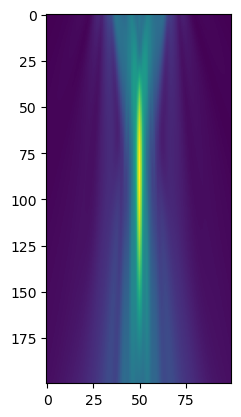

In [849]:
plt.imshow(P1.detach().numpy())

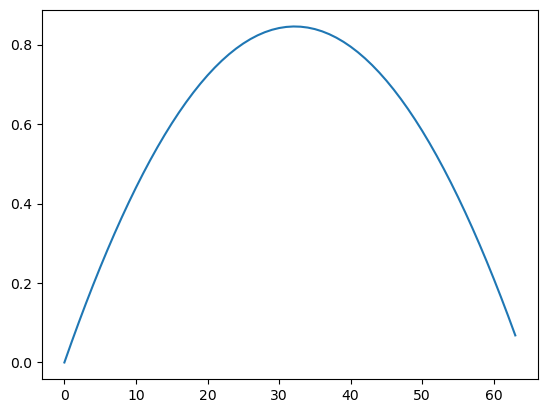

In [850]:
txdelay2 = pymust.txdelayFocused(param, X[100, 50], Z[100, 50])
plt.plot(txdelay2.flatten()*1e6)

In [851]:
P1, P_SPECT, IDX, outputs = pfield(X, [], Z, txdelay2, param, gradientsTx = True)
print(P1[100, 50])

tensor(6962.8120, grad_fn=<SelectBackward0>)


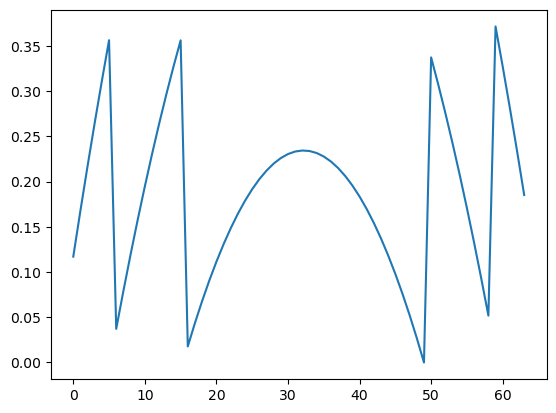

In [852]:
plt.plot(txdel.flatten()*1e6)

In [853]:
import scipy

In [ ]:
engineNP = Engine('numpy', 'cpu')
def f_opt(txdel):
    txdel = txdel - numpy.min(txdel)
    P1, P_SPECT, IDX, outputs = pfield(X, [], Z, txdel.reshape((1, param.Nelements)), param, gradientsTx = False, engine = engineNP)
    loss = - P1[100, 50]
    return loss 
X =scipy.optimize.minimize(f_opt, numpy.zeros((1, param.Nelements)), method='L-BFGS-B', jac=False, options={'disp': True, 'maxiter': 100})

/var/folders/s4/bzy_db252n15287qgjz2gfzh0000gn/T/ipykernel_10564/2280107457.py:7: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  X =scipy.optimize.minimize(f_opt, numpy.zeros((1, param.Nelements)), method='L-BFGS-B', jac=False, options={'disp': True, 'maxiter': 100})
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           64     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -1.75119D+03    |proj g|=  1.50662D+09
